In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('../../../')
from mount_drive import mount_s_drive

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from sklearn.datasets import make_classification


2025-02-17 16:59:51.992835: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-17 16:59:51.996398: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-17 16:59:52.008124: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1739829592.029274   11930 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739829592.035452   11930 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-17 16:59:52.056117: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [3]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.impute import KNNImputer


/home/idies/miniconda3/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [4]:
# pip install stepmix

In [4]:
myPredictorsDf = pd.read_csv('eICUPredictorsDiag.csv')

/tmp/ipykernel_11930/3248146962.py:1: DtypeWarning: Columns (14,16,41,51,63,65,66,76,80,89,99,111,113,114,124,128) have mixed types. Specify dtype option on import or set low_memory=False.
  myPredictorsDf = pd.read_csv('eICUPredictorsDiag.csv')


In [5]:
# myPredictorsDf.loc[myFilter, 'LastGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastGCS'].astype(int) > 8).astype(int
# myFilter = (myPredictorsDf['LastGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['LastGCS'].isna())
myFilter = (myPredictorsDf['LastMGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['LastMGCS'].isna())
myFilter = myFilter & (myPredictorsDf['FirstMGCSTime'] != myPredictorsDf['LastMGCSTime'])# & (myPredictorsDf['FirstGCSTime'] != myPredictorsDf['LastGCSTime'])
myPredictorsDf.loc[myPredictorsDf['FirstGCS'] == 'Unable to score due to medication', 'FirstGCS'] = np.nan
myPredictorsDf.loc[myPredictorsDf['FirstMGCS'] == 'Unable to score due to medication', 'FirstMGCS'] = np.nan
myPredictorsDf.loc[myPredictorsDf['LastMGCS'] == 'Unable to score due to medication', 'LastMGCS'] = np.nan
myPredictorsDf.loc[myPredictorsDf['LastGCS'] == 'Unable to score due to medication', 'LastGCS'] = np.nan
myPredictorsDf.loc[myPredictorsDf['DeathAtDischarge'] == 1, 'LastMGCS'] = 1
myPredictorsDf.gender = (myPredictorsDf.gender == 'Male').astype(int)
myPredictorsDf.LastGCS15 = 0
# myPredictorsDf.loc[myFilter, 'LastGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastGCS'].astype(float) > 8).astype(int)
myPredictorsDf.loc[myFilter, 'LastMGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastMGCS'].astype(float) == 6).astype(int)

In [6]:
myPredictorsDf.select_dtypes(include=['object']).columns

Index(['apacheadmissiondx', 'hospitaladmittime24', 'hospitaladmitsource',
       'FirstGCS', 'LastGCS', 'hospitaldischargestatus', 'firstGCS Total',
       'firstTemperature Location', 'firstValue', 'firstSedation Scale',
       'firstDelirium Scale', 'firstDelirium Score',
       'firstElectrolyte Replacement', 'firstFall Risk', 'lastGCS Total',
       'lastTemperature Location', 'lastValue', 'lastSedation Scale',
       'lastDelirium Scale', 'lastDelirium Score',
       'lastElectrolyte Replacement', 'lastFall Risk'],
      dtype='object')

In [7]:
myColumns = [x for x in myPredictorsDf.columns if 'emp' in x]
# myColumns = []
myXValue = myPredictorsDf.drop(columns= myColumns + [ 'LastMGCSTime', 'FirstMGCSTime', 'LastMGCSPositive', 'LastMGCS' , 'apacheadmissiondx', 'hospitaladmittime24', 'FirstGCSTime', 'LastGCSTime', 'LastGCS', 'hospitaldischargestatus', 'LastGCS15', 'hospitaladmitsource', 'DeathAtDischarge', 'patientunitstayid'])
myXValue = myXValue[myFilter]
myXValue.FirstGCS = myXValue.FirstGCS.astype(float)
myXValue.FirstMGCS = myXValue.FirstMGCS.astype(float)
myXValue = myXValue.select_dtypes(exclude=['object'])
column = 'LastMGCSPositive'
myYValue = myPredictorsDf[myFilter][column]
myYValue = myYValue.astype(int)

X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[myFilter][[column, 'Hypothermia']], test_size=0.3)

In [8]:
# myPredictorsDf

In [9]:
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 7) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    return [('preprocessor', myPreprocessor), ('imputer', KNNImputer(n_neighbors=10))]#, ( ('sfs', SFS(LogisticRegression(), 
         #  k_features='best', 
         #  forward=True, 
         #  floating=False, 
         #  scoring='roc_auc', 
         #  cv=3,
         # verbose=1,
         # n_jobs=-1))]
myPipelineSteps = getDefaultPipelineSteps(X_train)
myPipeline = Pipeline(myPipelineSteps)

In [10]:
myPipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder=OneHotEncoder(handle_unknown='ignore',
                                                           sparse_output=False),
                                   transformers=[('num', StandardScaler(),
                                                  Index(['age', 'admissionheight', 'admissionweight', 'FirstGCS', 'Lactate',
       'Troponin', 'Chloride', 'pH.1', 'Respiratory Rate.1',
       'Gentamicin - random',
       ...
       'meanPA Diastolic', 'maxPA Mean', 'minPA Mean', 'meanPA Me...
                                                  Index(['gender', 'PEA', 'Asystole', 'VTachy', 'VFib', 'Hypothermia', 'IAP',
       'firstQTc', 'firstPVRI', 'lastPVRI',
       ...
       'with subdural hematoma', 'with thrombolysis',
       'with upper airway involvement', 'with ventricular septal defect',
       'with vomiting', 'without foley catheter',
       'without hemodynamic compromise', 'witnessed, < 15 minutes CPR',
       'witnessed, > 15 minutes CPR', 'wound infection'],
      dtype='object', length=867))])),
                ('imputer', KNNImputer(n_neighbors=10))])

In [11]:
X_train_transf = myPipeline.fit_transform(X_train, y_train)
X_test_transf = myPipeline.transform(X_test)
X_train_transf = pd.DataFrame(X_train_transf, columns = myPipeline.get_feature_names_out())
X_test_transf = pd.DataFrame(X_test_transf, columns = myPipeline.get_feature_names_out())

In [12]:
X_train_transf.columns

Index(['num__age', 'num__admissionheight', 'num__admissionweight',
       'num__FirstGCS', 'num__Lactate', 'num__Troponin', 'num__Chloride',
       'num__pH.1', 'num__Respiratory Rate.1', 'num__Gentamicin - random',
       ...
       'remainder__with tension_0.0', 'remainder__with tension_nan',
       'remainder__without gangrene_0.0', 'remainder__without gangrene_nan',
       'remainder__without return to pre-existing conscious level_0.0',
       'remainder__without return to pre-existing conscious level_nan',
       'remainder__wound dehiscence_0.0', 'remainder__wound dehiscence_nan',
       'remainder__wound-associated_0.0', 'remainder__wound-associated_nan'],
      dtype='object', length=3335)

In [13]:
# [x for x in X_test_transf.columns if 'active' in x]

In [14]:
# input_dim = X_test_transf.shape[0]
# hidden_dim = 10000

# # Encoder
# autoencoder = keras.Sequential([
#     keras.Input(shape=(X_train_transf.shape[1],)),  
#     layers.Dense(10000, activation='relu'), 
#     layers.Dropout(0.2),
#     layers.Dense(5000, activation='relu'),
#     layers.Dropout(0.1),
#     layers.Dense(X_train_transf.shape[1], activation='sigmoid') 
# ])

# # Compile Autoencoder
# autoencoder.compile(optimizer="adam", loss="mse")
# myXValueTransf = myPipeline.transform(myXValue)
# autoencoder.fit(myXValueTransf, myXValueTransf, epochs=50, batch_size=32, verbose=1)

In [15]:
# X_train2, X_test2, y_train2, y_test2 = train_test_split(X_train_transf, y_train, stratify=y_train, test_size=0.3)
model = keras.Sequential([
    keras.Input(shape=(X_train_transf.shape[1],)),  
    layers.Dense(4000, activation='relu'), #6000
    layers.Dropout(0.2),#0.2
    layers.Dense(1000, activation='relu'),#2000
    layers.Dropout(0.1),#0.1
    # layers.Dense(1000, activation='relu'), 
    layers.Dense(500, activation='relu'), 
    # layers.Dense(200, activation='relu'), 
    layers.Dense(50, activation='relu'), 
    layers.Dense(16, activation='relu'), 
    layers.Dense(1, activation='sigmoid') 
])
# from tensorflow.keras.callbacks import EarlyStopping

# early_stopping = EarlyStopping(
#     monitor='loss',  # Metric to track
#     patience=10,          # Number of epochs to wait before stopping
#     restore_best_weights=True  # Restore the best model weights
# )

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name="roc_auc")])


2025-02-17 17:00:41.656744: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [ ]:
history = model.fit(X_train_transf, y_train, epochs=50, batch_size=32, validation_data=(X_test_transf, y_test))#, callbacks=[early_stopping])

Epoch 1/50


In [225]:
# model2 = XGBClassifier(max_depth=100)
# model2.fit(X_train_transf.to_numpy(), y_train)
# y_pred = model2.predict(X_test_transf)
# y_pred_proba = model2.predict_proba(X_test_transf)[:,1]
# print(f'acc: {accuracy_score(y_test, y_pred)}')
# print(f'roc auc: {roc_auc_score(y_test, y_pred_proba)}')

# y_pred = model2.predict(X_train_transf)
# y_pred_proba = model2.predict_proba(X_train_transf)[:,1]
# print(f'acc: {accuracy_score(y_train, y_pred)}')
# print(f'roc auc: {roc_auc_score(y_train, y_pred_proba)}')

acc: 0.6978947368421052
roc auc: 0.7710929456456137
acc: 1.0
roc auc: 1.0


In [174]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'roc_auc', 'val_accuracy', 'val_loss', 'val_roc_auc'])

In [175]:
# from scikeras.wrappers import KerasClassifier
# from mlxtend.feature_selection import SequentialFeatureSelector as SFS

# # Assuming you have a function to build your Keras model
# def build_model():
#     model = keras.Sequential()
#     model.add(layers.Dense(64, activation='relu', input_shape=(X_train_transf.shape[1],)))
#     model.add(layers.Dense(32, activation='relu'))
#     model.add(layers.Dense(1, activation='sigmoid'))  # For binary classification
#     model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
#     return model

# # Wrap the model with KerasClassifier
# model_wrapper = KerasClassifier(model=build_model, epochs=10, batch_size=32, verbose=1)

# # Use the wrapped model in SFS
# sfs = SFS(LogisticRegression(), 
#           k_features='best', 
#           forward=True, 
#           floating=False, 
#           scoring='roc_auc', 
#           cv=3,
#          verbose=1,
#          n_jobs=-1)

# sfs.fit(X_train_transf, y_train)


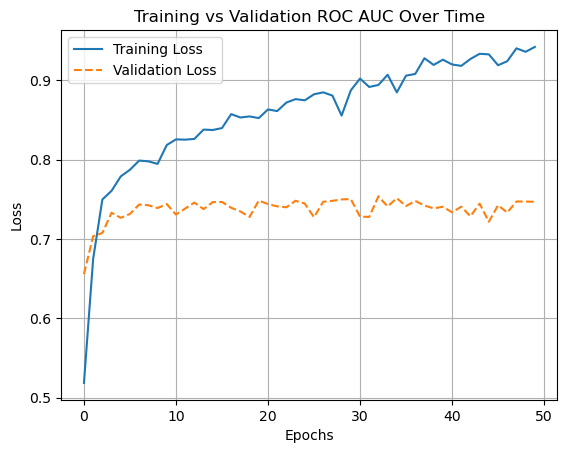

In [67]:
# Extract loss values
train_loss = history.history['roc_auc']
val_loss = history.history['val_roc_auc']

# Plot training & validation loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss', linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation ROC AUC Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
# X_train_transf.shape

(1746, 1360)

In [113]:
y_pred_probs = model.predict(X_test_transf)  # Probabilities

# Compute ROC AUC
roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
ROC AUC Score: 0.7268


In [119]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Sample Dataset (Replace with real data)
# X = np.random.rand(1000, 20)  # 1000 samples, 20 features
# y = np.random.randint(0, 2, size=(1000,))  # Binary classification (0 or 1)

# Define Model Function
def create_model(optimizer="adam", neurons=16, activation="relu"):
    model = keras.Sequential([
        layers.Dense(neurons, activation=activation, input_shape=(X_train_transf.shape[1],)),
        layers.Dropout(0.3),
        layers.Dense(neurons // 2, activation=activation),
        layers.Dense(1, activation="sigmoid")  # Binary classification
    ])
    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])
    return model

# Wrap model using scikeras
model = KerasClassifier(model=create_model, verbose=0)

# Define Hyperparameter Grid
param_grid = {
    "model__optimizer": ["adam", "rmsprop", "sgd"],
    "model__neurons": [8, 16, 32, 64],
    "model__activation": ["relu", "tanh"],
    "batch_size": [16, 32, 64],
    "epochs": [10, 20, 30, 50]
}

# Use RandomizedSearchCV for faster tuning
random_search = RandomizedSearchCV(model, param_distributions=param_grid, cv=3, n_iter=10, scoring="accuracy", verbose=1)
random_search.fit(X_train_transf, y_train)

# Best Model and Hyperparameters
print("Best Hyperparameters:", random_search.best_params_)
print("Best AUC:", random_search.best_score_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits


/home/idies/miniconda3/lib/python3.9/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/idies/miniconda3/lib/python3.9/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/idies/miniconda3/lib/python3.9/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activi

Best Hyperparameters: {'model__optimizer': 'rmsprop', 'model__neurons': 32, 'model__activation': 'relu', 'epochs': 20, 'batch_size': 16}
Best AUC: 0.6723940435280641


In [163]:
# import shap
# import numpy as np

# # Ensure your data is in numpy array format for SHAP
# X_train_np = X_train_transf.to_numpy()

# # Explain predictions using KernelExplainer (for any model)
# explainer = shap.KernelExplainer(model.predict, X_train_np)

# # Compute SHAP values (only for a sample to speed up computation)
# shap_values = explainer.shap_values(X_train_np[:100])  # Use a subset to reduce compute time

# # Get mean absolute SHAP values for feature importance
# shap_importance = np.abs(shap_values).mean(axis=0)

# # Sort and display feature importance
# feature_importance_df = pd.DataFrame({
#     'Feature': X_train_transf.columns,
#     'SHAP Importance': shap_importance
# }).sort_values(by='SHAP Importance', ascending=False)

# print(feature_importance_df)


In [41]:
# selected_features = X_train_transf.columns[selector.support_]
# X_train_transf[selected_features]

AttributeError: 'RFECV' object has no attribute 'support_'

In [ ]:
myFeatureImportancesDf = getTopFeatures(myGridSearchCv, list(myBestModel.named_steps.preprocessor.get_feature_names_out()), X_train, y_train)

In [68]:
DefaultGrid = [
    {
        'clf': [XGBClassifier(eval_metric='logloss'), RandomForestClassifier()],
        'clf__n_estimators': [5, 10, 50, 200, 500], 
        'clf__max_depth': [2, 5, 10, 25, None]
    },
    {
        'clf': [DecisionTreeClassifier()],
        'clf__max_depth': [2, 5, 20, 50, None],
        'clf__class_weight': [None, 'balanced']
    },
    {
        'clf': [LogisticRegression(), SVC(probability=True, kernel='linear')],
        'clf__C': [0.1, 1, 10]
    }
]
def getPredictedTreatmentEffectSupervisedClassif(X_train, aModel, aCategory, aGroup):
    myXValueModified1 = X_train.copy()
    myXValueModified1[aGroup] = 1.0
    myXValueModified2 = X_train.copy()
    myXValueModified2[aGroup] = 0.0
    if hasattr(aModel, 'predict_proba'):
        y_pred_proba1 = aModel.predict_proba(myXValueModified1)[:, 1]
        y_pred_proba2 = aModel.predict_proba(myXValueModified2)[:, 1]
    else:
        y_pred_proba1 = aModel.predict(myXValueModified1).T[0]
        y_pred_proba2 = aModel.predict(myXValueModified2).T[0]
    myNewDf = pd.DataFrame()
    # print(y_pred_proba1)
    myNewDf['predicted_effect'] = (y_pred_proba1 - y_pred_proba2)
    
    return plotPredictedTreatmentEffect(myNewDf=myNewDf, aCategory=aCategory)
def getTreatmentEffectDiff(X_train, y_train, aModel, aCategory = 'CPC12', aGroup = 'groupe'):
    lower_third, upper_third, myNewDf = getPredictedTreatmentEffectSupervisedClassif(X_train, aModel, aCategory, aGroup)
    print(lower_third)
    print(upper_third)
    if upper_third == lower_third:
        print(f'No effect difference')
        return 1
    myData = pd.concat([X_train[aGroup], myNewDf['predicted_effect'], y_train], axis=1)
    model1 = smf.logit(
        f'{aCategory} ~ predicted_effect + {aGroup}',
        data=myData
    ).fit()

    model2 = smf.logit(
        f'{aCategory} ~ predicted_effect * {aGroup}',
        data=myData
    ).fit()

    llr = -2*(model1.llf - model2.llf)
    df_diff = model2.df_model - model1.df_model
    p_value = chi2.sf(llr, df_diff)

    print(f'Likelihood ratio of test results:')
    print(f'Chi square statistic: {llr}')
    print(f'p-value: {p_value}')
    print(f'Degress of freedom: {df_diff}')
    print(f'NonInteraction p-value: {model1.summary()}')
    print(f'Interaction p-value: {model2.summary()}')
    return p_value

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
0.009035453200340271
0.012564986944198607
Optimization terminated successfully.
         Current function value: 0.692111
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.691966
         Iterations 4
Likelihood ratio of test results:
Chi square statistic: 0.2877061577960376
p-value: 0.5916942418665654
Degress of freedom: 1.0
NonInteraction p-value:                            Logit Regression Results                           
Dep. Variable:       DeathAtDischarge   No. Observations:                  989
Model:                          Logit   Df Residuals:                      986
Method:                           MLE   Df Model:                            2
Date:                Sun, 16 Feb 2025   Pseudo R-squ.:                0.001329
Time:                        18:20:28   Log-Likelihood:                -684.50
converged:                       True   LL-Null: 

0.5916942418665654

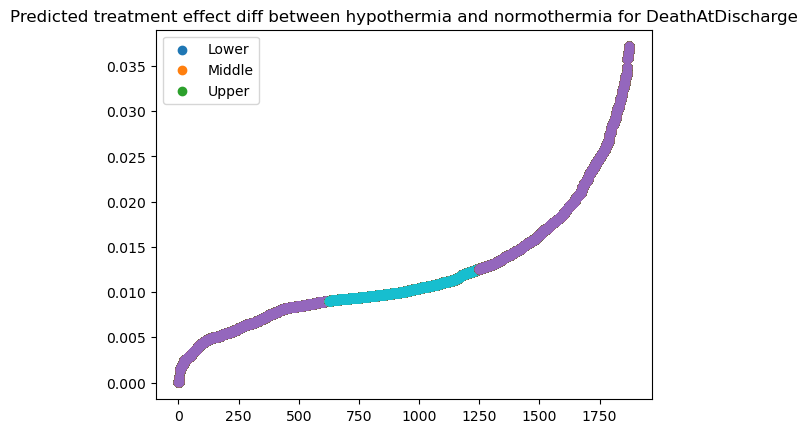

In [81]:
# getTreatmentEffectDiff(myXValue, myYValue, myBestModel, 'LastGCS15', 'Hypothermia')
# myNewDf = pd.DataFrame()
# myNewDf['predicted_effect_group'] = myBestModel.predict(X_test)
getTreatmentEffectDiff(X_train_transf, y_train, model, 'DeathAtDischarge', 'bin__Hypothermia')

In [ ]:
# def policy_risk(y_0, y_1, predicted_ite, t):
#     """
#     Computes policy risk using observed outcomes.

#     Args:
#         y_0 (numpy array): Observed outcomes for control group (when T=0).
#         y_1 (numpy array): Observed outcomes for treated group (when T=1).
#         predicted_ite (numpy array): Model's predicted individual treatment effect.
#         t (numpy array): Treatment assignment (1 for treated, 0 for control).

#     Returns:
#         float: Estimated policy risk.
#     """
#     factual_outcomes = np.where(t == 1, y_1, y_0)
#     recommended_treatment = (predicted_ite > 0).astype(int)
#     expected_outcome = np.where(recommended_treatment == 1, y_1, y_0)
    
#     return np.mean(factual_outcomes - expected_outcome)


# # predicted_ite = model.predict(

# policy_risk_value = policy_risk(y_0, y_1, predicted_ite, t)
# print("Policy Risk:", policy_risk_value)


In [56]:
[x for x in X_train_transf.columns if 'Hyp' in x]

['bin__Hypothermia']

-0.006000000000000005
0.001999999999999974
Optimization terminated successfully.
         Current function value: 0.654791
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.654027
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 1.0572722026490737
p-value: 0.589408314933102
Degress of freedom: 2.0
NonInteraction p-value:                            Logit Regression Results                           
Dep. Variable:       LastMGCSPositive   No. Observations:                  692
Model:                          Logit   Df Residuals:                      688
Method:                           MLE   Df Model:                            3
Date:                Sun, 02 Feb 2025   Pseudo R-squ.:                 0.01808
Time:                        19:09:05   Log-Likelihood:                -453.12
converged:                       True   LL-Null:                       -461.46
Covariance Type:            nonrobust   LLR p-valu

0.589408314933102

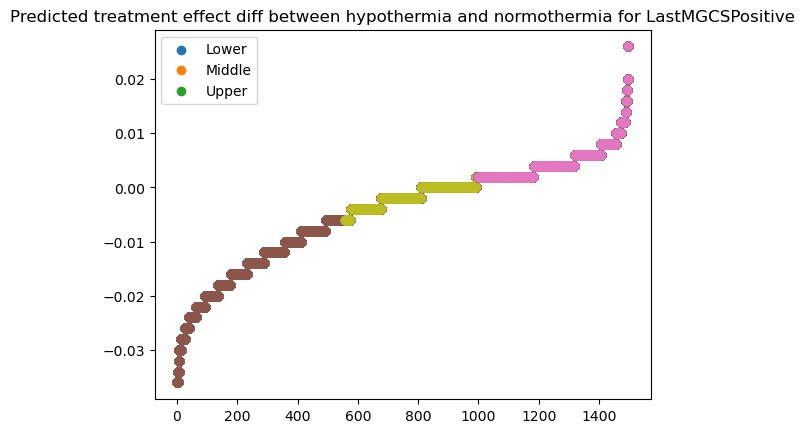

In [29]:
getTreatmentEffectDiff(X_train, y_train, myBestModel, 'LastMGCSPositive', 'Hypothermia')

0.3871829105473965